In [ ]:
import torch 
import numpy as np

def initialize_population(pop_size, length):
    return [torch.randint(0, 3, (length,)) for _ in range(pop_size)]

def mutate(individual, mutation_rate=0.05):
    new = individual.clone()
    for i in range(len(new)):
        if torch.rand(1).item() < mutation_rate:
            new[i] = torch.randint(0, 3, (1,)).item()
    return new

def crossover(parent1, parent2):
    point = torch.randint(1, len(parent1)-1, (1,)).item()
    child = torch.cat([parent1[:point], parent2[point:]])
    return child

def select_top(population, scores, top_k):
    sorted_indices = np.argsort(scores)[::-1]
    return [population[i] for i in sorted_indices[:top_k]]

def evaluate_schedule(schedule_96, df_test, idx_start, model_temp, model_rh, scaler_temp, scaler_rh):
    schedule = np.array(schedule_96, dtype=int)

    df_test_copy = df_test.copy()
    df_test_copy.loc[df_test_copy.index[idx_start:idx_start+96], 'hvac_mode'] = schedule

    preds_temp = predict_Tin_sequence_full(
        df_test_copy, 
        window_start_idx=idx_start, 
        lstm_model=model_temp['lstm'], 
        rf_model=model_temp['rf'], 
        scaler=model_temp['scaler'],
        window_size=6,
        n_steps=96
    )

    preds_rh = predict_RH_sequence_full(  
        df_test_copy, 
        window_start_idx=idx_start, 
        lstm_model=model_rh['lstm'], 
        rf_model=model_rh['rf'], 
        scaler=model_rh['scaler'],
        window_size=6,
        n_steps=96
    )

    tin_series = preds_temp['Tin_pred'].values
    rh_series = preds_rh['RH_pred'].values
    return compute_simple_comfort(tin_series, rh_series)

def optimize_hvac_schedule(
    df_test,
    idx_start,
    model_temp,
    model_rh,
    pop_size=30,
    generations=30,
    top_k=10,
    mutation_rate=0.1
):
    population = initialize_population(pop_size, 96)

    for gen in range(generations):
        scores = []
        for ind in population:
            hvac_schedule = ind.tolist()
            score = evaluate_schedule(hvac_schedule, df_test, idx_start, model_temp, model_rh)
            scores.append(score)

        print(f"Gen {gen} - Best comfort score: {np.max(scores):.2f}")

        elites = select_top(population, scores, top_k)

        new_population = []
        while len(new_population) < pop_size:
            parents = np.random.choice(elites, size=2, replace=False)
            child = crossover(parents[0], parents[1])
            child = mutate(child, mutation_rate)
            new_population.append(child)

        population = new_population

    best_idx = np.argmax(scores)
    return population[best_idx].tolist()

In [ ]:
best_schedule = optimize_hvac_schedule(
    df_test=df,               # your full dataset
    idx_start=5000,           # start index of the 96-step forecast
    model_temp={
        'lstm': my_temp_lstm,
        'rf': my_temp_rf,
        'scaler': my_temp_scaler
    },
    model_rh={
        'lstm': my_rh_lstm,
        'rf': my_rh_rf,
        'scaler': my_rh_scaler
    }
)

print("Best HVAC schedule (0=OFF, 1=LOW, 2=HIGH):")
print(best_schedule)

In [1]:
# NEW CODE
import numpy as np
import importlib
import pandas as pd
import os
import random
import joblib
from pythermalcomfort.models import pmv_ppd_iso
import torch
import Hvac_predict_script

importlib.reload(Hvac_predict_script)
from Hvac_predict_script import predict_Tin_sequence_full, LSTMWithFuture

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)

test_start = pd.Timestamp('2023-01-22')
test_end = pd.Timestamp('2023-01-29')

df = dfs[0].copy()

df.drop(index=df[df['total_energy'] == 0.0].index, inplace=True)


df['T_diff'] = (df['Tout'] - df['Tin']).bfill()
df['hour'] = df.index.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month'] = df.index.month

# results.append({
#         'timestamp': df_test.index[idx],
#         'Tin_pred': Tin_pred,
#         'Tin_true': row['Tin'],
#         'hvac_mode': hvac_mode,
#         'Tin_target': row['Tin_target'],
#         'RH_pred': RH_pred,
#         'RH_true': row['RH'],
# })
tin_model = LSTMWithFuture(input_size=3, hidden_size=128, num_layers=2)
tin_model.load_state_dict(torch.load('best_model_tin.pt'))
rh_model = LSTMWithFuture(input_size=7, hidden_size=128, num_layers=2)
rh_model.load_state_dict(torch.load('best_model_rh.pt'))

scaler_tin = joblib.load('scaler_tin.pkl')
scaler_rh = joblib.load('scaler_rh.pkl')

df['Tin_target']  = df['Tin'].shift(-1).dropna()          
df['is_test'] = (df.index >= test_start) & (df.index <= test_end)
df['RH_target'] = df['RH'].shift(-1)

df['hvac_mode'] = 0 
on_mask = df['hvac_energy'] > 0
nonzero_power = df.loc[on_mask, 'hvac_energy']
bins = pd.qcut(nonzero_power, q=2, labels=[1, 2])
df.loc[on_mask, 'hvac_mode'] = bins.astype(int).values

df_test = df[df['is_test']].copy()
df_encoded_test = df_test.copy()
df_encoded_test = df_encoded_test.join(pd.get_dummies(df_test['hvac_mode'], prefix='hvac'))

rf_model = joblib.load('best_model_rf.pkl')

import random

def generate_schedule():
    return [random.choice([0, 1, 2]) for _ in range(96)]

def calculate_overall_comfort(list_tin, list_rh):
    ppd_values = []
    for tin, rh in zip(list_tin, list_rh):
        comfort = pmv_ppd_iso(
            tdb=tin,
            tr=tin,     # assume radiant = air temp
            vr=0.1,     # air speed
            rh=rh,
            met=1.1,    # metabolic rate (seated)
            clo=1.0     # light clothing
        )
        if comfort['ppd'] is None:
            print(tin)
            ppd_values.append(75)  # handle None PPD gracefully
        else:
            # print(comfort['ppd'], comfort['pmv'])
            ppd_values.append(comfort['ppd'])  # store only PPD
    return ppd_values  # list of 96 PPD values

def evaluate_schedule(schedule = None):
    if schedule is None:
        schedule = generate_schedule()

    results = predict_Tin_sequence_full(        
        df_test=df_encoded_test,  
        window_start_idx=10,       
        lstm_model=tin_model,     
        rf_model=rf_model,  
        tin_scaler=scaler_tin,   
        rh_model=rh_model,        
        rh_scaler=scaler_rh,     
        n_steps=96,
        hvac_schedule=schedule             
    )
    tin_pred = results['Tin_pred'].values
    rh_pred = results['RH_pred'].values
    ppd_list = calculate_overall_comfort(tin_pred, rh_pred)  
    
    avg_ppd = 100 - np.mean(ppd_list)
    print(f"Average comfort percentage: {avg_ppd:.2f}")
    # switches = count_switches(schedule)
    # if switches > 20:
    #     avg_ppd += 0.5  # soft penalty
    
    # return avg_ppd

def count_switches(schedule):
    """Count how many times the HVAC setting changes in the schedule."""
    return sum(1 for i in range(1, len(schedule)) if schedule[i] != schedule[i-1])

evaluate_schedule()
# comfort = pmv_ppd_iso(
#     tdb=19.5,
#     tr=19.5,     # assume radiant = air temp
#     vr=0.1,     # air speed
#     rh=30.0,
#     met=1.1,    # metabolic rate (seated)
#     clo=1.0     # light clothing
# )
# print(comfort)

Average comfort percentage: 81.17


In [3]:
import pygad
import numpy as np

hvac_choices = [0, 1, 2]

def fitness_func(ga_instance, solution, solution_idx):
    schedule = [int(x) for x in solution]  
    results = predict_Tin_sequence_full(
        df_test=df_encoded_test,
        window_start_idx=10,
        lstm_model=tin_model,
        rf_model=rf_model,
        tin_scaler=scaler_tin,
        rh_model=rh_model,
        rh_scaler=scaler_rh,
        n_steps=96,
        hvac_schedule=schedule
    )
    tin_pred = results['Tin_pred'].values
    rh_pred = results['RH_pred'].values
    list_rh = df_test['RH'].iloc[10:10 + 96].tolist()

    ppd_list = calculate_overall_comfort(tin_pred, list_rh)
    avg_ppd = np.nanmean(ppd_list)
    
    return 100 - avg_ppd  

gene_space = hvac_choices
num_genes = 96

ga_instance = pygad.GA(
    num_generations=120,
    num_parents_mating=15,
    fitness_func=fitness_func,
    sol_per_pop=40,
    num_genes=num_genes,
    gene_space=gene_space,
    parent_selection_type="tournament",
    keep_parents=4,
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    stop_criteria=["saturate_30"]
)

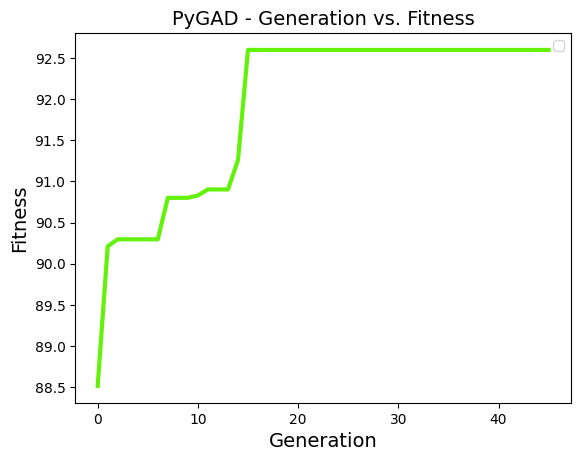

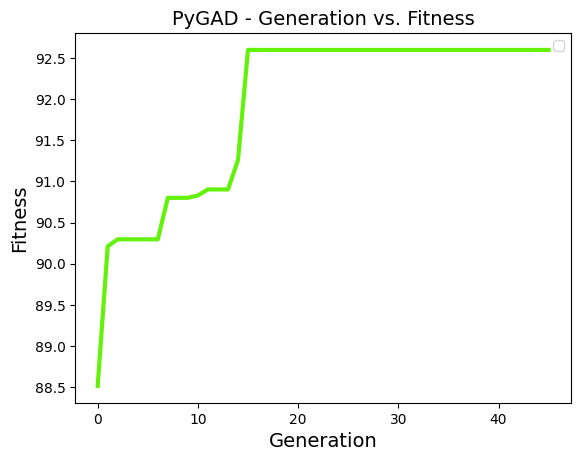

In [4]:
ga_instance.run()
ga_instance.plot_fitness()

In [5]:
solution, fitness, _ = ga_instance.best_solution()
best_schedule = [int(x) for x in solution]
print("Best schedule:", best_schedule)
print("Best avg comfort score (100 - PPD):", fitness)

Best schedule: [2, 2, 1, 2, 2, 0, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 2, 2, 2, 1, 2, 0, 2, 2, 1, 2, 2, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1, 0, 0, 1, 2, 2, 1, 1, 2, 0, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 0, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 2, 0, 1, 0, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 0, 2, 1, 1, 2, 0]
Best avg comfort score (100 - PPD): 92.6


In [50]:
def evaluate_ground_truth_comfort(df_test, window_start_idx):
    # Extract the 96-step ground truth Tin and RH from the test data
    list_tin = df_test['Tin'].iloc[window_start_idx:window_start_idx + 96].tolist()
    list_rh = df_test['RH'].iloc[window_start_idx:window_start_idx + 96].tolist()

    # Compute PPD using the actual values
    ppd_list = calculate_overall_comfort(list_tin, list_rh)
    avg_ppd = np.nanmean(ppd_list)

    comfort_score = 100 - avg_ppd
    print("Ground Truth Comfort Score (100 - avg PPD):", round(comfort_score, 2))

    return comfort_score

evaluate_ground_truth_comfort(df_encoded_test, window_start_idx=10)


Ground Truth Comfort Score (100 - avg PPD): 77.54


np.float64(77.54062499999999)

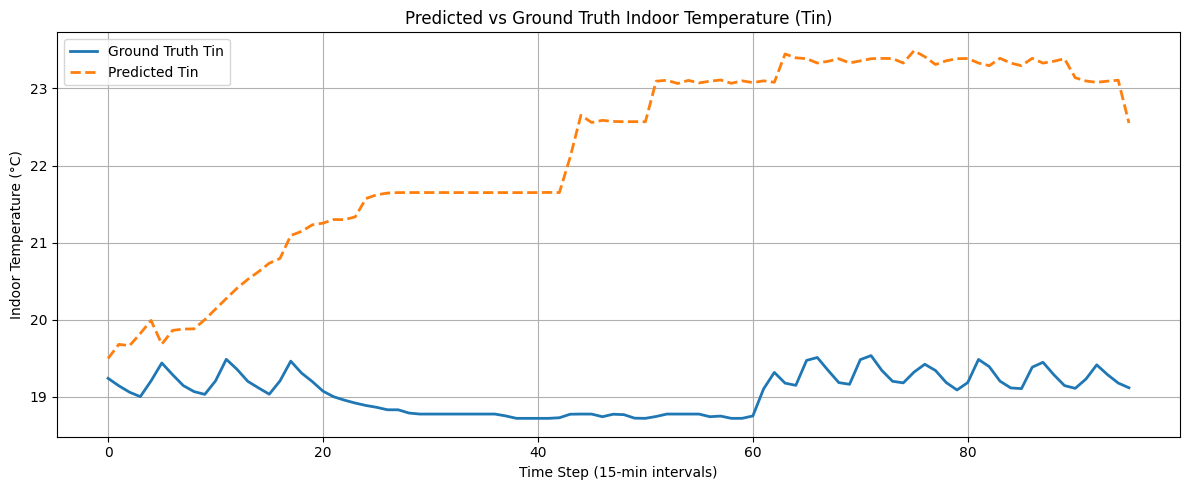

Ground Truth Comfort Score (100 - avg PPD): 77.87


In [ ]:
import matplotlib.pyplot as plt
# print(test)
results = predict_Tin_sequence_full(        
    df_test=df_encoded_test,  
    window_start_idx=10,       
    lstm_model=tin_model,     
    rf_model=rf_model,  
    tin_scaler=scaler_tin,   
    rh_model=rh_model,        
    rh_scaler=scaler_rh,     
    n_steps=96,
    hvac_schedule=best_schedule             
)

def plot_tin_prediction_vs_ground_truth(results):
    predicted_tin = results['Tin_pred'].values

    ground_truth_tin = results['Tin_target'].values

    # Time axis (in 15-minute steps)
    time_steps = range(96)

    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(time_steps, ground_truth_tin, label='Ground Truth Tin', linewidth=2)
    plt.plot(time_steps, predicted_tin, label='Predicted Tin', linestyle='--', linewidth=2)
    plt.xlabel("Time Step (15-min intervals)")
    plt.ylabel("Indoor Temperature (°C)")
    plt.title("Predicted vs Ground Truth Indoor Temperature (Tin)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_tin_prediction_vs_ground_truth(results)
list_tin = results['Tin_target'].values
list_rh = results['RH_true'].values
# Compute PPD using the actual values
ppd_list = calculate_overall_comfort(list_tin, list_rh)
avg_ppd = np.nanmean(ppd_list)

comfort_score = 100 - avg_ppd
print("Ground Truth Comfort Score (100 - avg PPD):", round(comfort_score, 2))



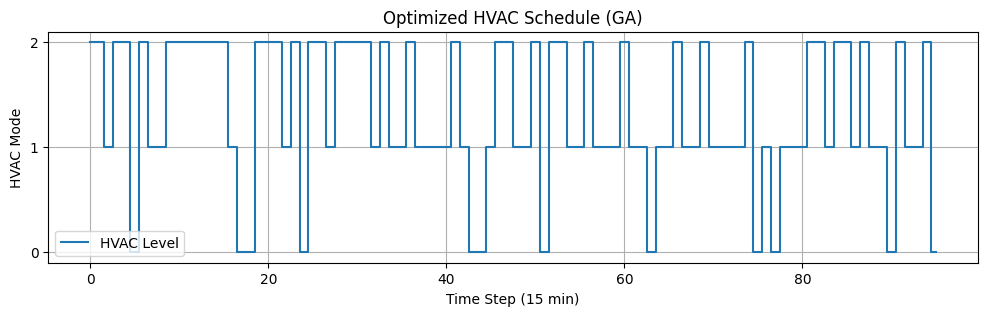

In [7]:
plt.figure(figsize=(12, 3))
plt.step(range(96), best_schedule, where='mid', label='HVAC Level')
plt.yticks([0, 1, 2])
plt.xlabel("Time Step (15 min)")
plt.ylabel("HVAC Mode")
plt.title("Optimized HVAC Schedule (GA)")
plt.grid(True)
plt.legend()
plt.show()